In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri May 12 15:45:12 2023

@author: Alex Perez Bellido
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
import time
import multiprocessing as mp
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, wilcoxon
import matplotlib.pylab as pl
import os, glob, platform, sys

import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm

from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)




In [2]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']

colpal1b = ['dodgerblue','navy']
colpal3 = ['green','darkviolet']
colpal3a = ['green','darkviolet','darkgrey']
colpal2 = ['gold','mediumturquoise','darkblue']


In [3]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
 
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home','freeman','Insync', 'alexisperez@ub.edu', 'OneDrive Biz')  # Linux   
    results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet

figures_path = os.path.join(results_path, 'Group_level_analyses','figures') 
# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

#import psychofit as psy

# path
hddm_m_path = os.path.join(results_path,'Group_level_analyses','hddm_models')

In [4]:
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g

Setting paths---

Concatenating datasets

__preparing stims for simulations__

Creating a synthetic dataset

__Functions__

In [5]:
def sinusoidal_function(x, min_amp, max_amp, frequency_hz, phase_shift):
    omega = 2 * np.pi * frequency_hz
    amplitude = (max_amp - min_amp) / 2
    offset = (max_amp + min_amp) / 2
    return amplitude * np.sin(omega * x + phase_shift) + offset


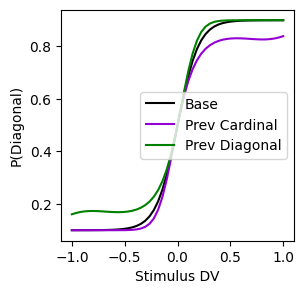

In [6]:
threshold = -0.0 # Threshold for detecting the stimulus
slope = 10  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity

# Generate stimulus intensities
stimulus_intensities = np.linspace(-1, 1, 50)

# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high, prev_sens, wbias):
    w = sinusoidal_function(x, -1, 1, 0.25, prev_sens ) * wbias
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + w )* (x - threshold))))
    return prob


#def decimetric_function(x, threshold, slope, lapse_low, lapse_high, slp_coef, slp_phase):
#    slp_weight = sinusoidal_function(x, -1, 1, 0.25, slp_phase) # min val and max value, frequency and phase
#    slope = slope + (slp_coef * slp_weight)
#    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope * (x - threshold))))
#    deci = np.random.uniform(0, 1, size=len(prob))  < prob  # Use vectorized comparison #np.random.uniform(0, 1, size=len(prob))
#    return deci.astype(int)  # Convert boolean values to integers (0 or 1)



# Visualize the probabilities of discriminating C vs D
prob_detect_b = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(180),0)

prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(180),0.75*10)
prob_detectb = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high,np.deg2rad(0),0.75*10)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect_b,'black', label='Base')
plt.plot(stimulus_intensities, prob_detect,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detectb,'green', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

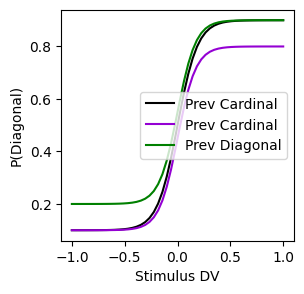

In [7]:
# Define the psychometric function with lapses
def psychometric_function(x, threshold, slope, lapse_low, lapse_high):
    prob = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-(slope + 10)* (x - threshold))))
    return prob

threshold = -0.0 # Threshold for detecting the stimulus
slope = 0.5  # Slope of the psychometric function
lapse_low = 0.1  # Lapse rate for low stimulus intensity
lapse_high = 0.1  # Lapse rate for high stimulus intensity


# Visualize the probabilities of discriminating C vs D
prob_detect = psychometric_function(stimulus_intensities, threshold, slope, lapse_low, lapse_high)
prob_detect_C = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low, lapse_high + 0.1)
prob_detect_D = psychometric_function(stimulus_intensities, threshold, slope + 1, lapse_low + 0.1, lapse_high)

plt.figure(figsize=(3,3))

# Plot the psychometric curve
plt.plot(stimulus_intensities, prob_detect, 'black', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_C,'darkviolet', label='Prev Cardinal')
plt.plot(stimulus_intensities, prob_detect_D,'green', label='Prev Diagonal')
plt.xlabel('Stimulus DV')
plt.ylabel('P(Diagonal)')
plt.legend()
plt.show()

In [8]:
def rescale_matrix(matrix):
    """
    Rescales the matrix using z-scoring (standardization).
    Subtracts the mean and divides by the standard deviation, calculated globally.
    """
    mean_val = np.mean(matrix)
    std_val = np.std(matrix)

    # Avoid division by zero if the matrix has zero variance (e.g., all identical values)
    if std_val == 0:
        # Handle this case: perhaps return the matrix centered at 0, or just the original
        # Returning a zero matrix might be safest if std is 0
        scaled_matrix = matrix - mean_val
    else:
        scaled_matrix = (matrix - mean_val) / std_val

    return scaled_matrix



def create_exp():
    ntrials = 5000
    tseries = 500 # stim time 
    tseries_nostim = 200 # stim time
    stim_strengh = 0.4
    stim_var = 3
    nreps = 2

    # random data with a bias (stimulus)
    stim_data = np.random.normal(stim_strengh, stim_var, (ntrials, tseries))
    # randomizingg sign of the data for different trials options (+1 or -1 stimuli)
    stim_vector = np.random.choice([-1, 1], size=stim_data.shape[0])
    stim_data *= stim_vector[:, np.newaxis] # applying to the vectors

    stim_data = np.repeat(stim_data, nreps, axis = 0) # duplicating trials per number of repetitions
    mean_stim = np.mean(stim_data, axis = 1) # mean of energy of the stimulus in stimulus time

    # generating unbiased data (no stimulus)
    nostim_data = np.random.normal(0, stim_var, (ntrials*nreps, tseries_nostim))

    # combine data with stim and without stim
    sim_data = np.concatenate((stim_data,nostim_data), axis = 1)
    sim_data = rescale_matrix(sim_data) # rescale data between -1 and 1

    stim_vector = np.repeat(stim_vector, nreps, axis = 0)
    trial_rep = np.tile(np.array([0,1]), ntrials) # trial rep index

    # Concatenate the arrays along axis 1
    result = np.concatenate([stim_vector.reshape(-1, 1), trial_rep.reshape(-1, 1), mean_stim.reshape(-1, 1)], axis=1)
    sim_df = pd.DataFrame(result, columns=['stim', 'nrep','DV'])
    sim_df['pre_deci'] = np.random.choice([-1, 1], size=sim_df.shape[0]) # initialize random preresp 
    sim_df['deci'] = 0 
    sim_df['RT'] = 0
    return sim_df, sim_data


def psychometric_function_with_lapses(x, threshold, slope, lapse_low, lapse_high):
    return lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope  * (x - threshold))))

def decimetric_function(x, threshold, slope, lapse_low, lapse_high, slp_coef, slp_phase):
    probs = lapse_low + (1 - lapse_low - lapse_high) * (1 / (1 + np.exp(-slope * (x - threshold))))
    #deci = np.random.uniform(0, 1, size=len(prob))  < prob  # Use vectorized comparison #np.random.uniform(0, 1, size=len(prob))
    return probs  # Convert boolean values to integers (0 or 1)

# this function is to compare two matrices and set to zero the values that are different     
def compare_and_set_to_zero(m1, m2):
    result = np.copy(m1)
    for i in range(m1.shape[0]):
        for j in range(m1.shape[1]):
            if np.sign(m1[i][j]) != np.sign(m2[i][j]):
                result[i][j] = 0
    return result


# This function makes the whole simulation using the different funtions and returns a dataframe with the results

def sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par):
    starting_bias = ddm_par['p_z']
    
    for inrep in [0,1]: # iterate over number of repetitions
        
        idx_nrep = sim_df[sim_df['nrep'] == inrep].index
        stims_samp = sim_data[idx_nrep, :]
        stims_samp = stims_samp.T   
        ddm_par['p_z'] = 0
        #prev_deci = df_sample['deci'].values

        # all this below should be a function
        # Initializing parameters matrixes
        thresholds = np.ones(stims_samp.shape) * obs_knel['threshold_val'] #+ np.random.normal(0, 0.1, 1) # adding some random variability to each simulated subject
        slopes = np.ones(stims_samp.shape) * obs_knel['slope_val'] #+ np.random.normal(0, 3, 1) # adding some random variability to each simulated subject
        lapses_low = np.ones(stims_samp.shape) * obs_knel['lapse_high_val']     # + lapse_bias * prev_deci
        lapses_high = np.ones(stims_samp.shape) * obs_knel['lapse_low_val']    # + lapse_bias * prev_deci

        prev_choice = np.random.choice([0, 1], size=stims_samp.shape[1])  #np.zeros(stims_samp.shape[1]) # for the first rep, just fill with zeros or ones
        slopephasesMat = np.zeros(stims_samp.shape[1]) # for the first rep, just fill with zeros
        slp_coef = 0

        # in first rep, initialize slope coef in 0

        if inrep > 0: # only previous history can affect after nrep = 0
           
            prev_choice =  np.sign(choice) #() #np.roll(choice,1)
            ddm_par['p_z'] = starting_bias
            
            #print(prev_choice)

            # changing lapses depending on previous choice
            # for cardinal
            prev_choice_diag = prev_choice.copy()
            prev_choice_diag[prev_choice_diag == -1] = 0
            prev_choice_diag = np.tile(prev_choice_diag, (stims_samp.shape[0], 1))
            # for diagonals
            prev_choice_card = prev_choice.copy()
            prev_choice_card[prev_choice_card == 1] = 0
            prev_choice_card = np.abs(prev_choice_card)
            prev_choice_card = np.tile(prev_choice_card, (stims_samp.shape[0], 1))

            # changing lapses depending on previous choice
            lapses_low = lapses_low + (bias_par['lapse_bias'] * prev_choice_diag) # change low lapse if previous choice was diagonal
            lapses_high = lapses_high + (bias_par['lapse_bias'] * prev_choice_card) # change high lapse if previous choice was cardinal

            # changing threshold depending on previous choice
            thresholds = thresholds + bias_par['threshold_bias'] * (prev_choice * -1)
            
            slopes = slopes + bias_par['slope_change'] # we increase the slope 
            
           
            # slopes = slopes + bias_par['slope_val_bias'] * prev_choice
            # changing slope (phase of sinusoidal) depending on previous choice
            slopephasesMat = prev_choice.copy()
            slopephasesMat[slopephasesMat == 1] = np.deg2rad(0)
            slopephasesMat[slopephasesMat == -1] = np.deg2rad(180)
            slp_coef = bias_par['slope_val_bias']
            
        # Calculate the probabilities for each element in the matrices
        #probs = psychometric_function_with_lapses(stims_samp, thresholds, slopes, lapses_low, lapses_high)
        probs = decimetric_function(stims_samp, thresholds, slopes, lapses_low, lapses_high, slp_coef, slopephasesMat)
        E = DDM_fun(probs,ddm_par,stim_par,  prev_choice, stims_samp) 
        
        if inrep == 0:
            traces = E.copy()
        else:
            # concatenate the traces
            traces = np.concatenate([traces,E],axis=1)
        
        
        choice, rts = bound_fun(E, ddm_par['bound'])
        # plot traces
        plt.plot(E[:,0:100], lw = 0.25)

        # concatenating everything in the dataframe
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('deci')] = np.sign(choice)
        sim_df.loc[sim_df['deci'] == -1, 'deci'] = 0
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('RT')] = rts
        sim_df.iloc[idx_nrep, sim_df.columns.get_loc('pre_deci')] = prev_choice
        sim_df.loc[sim_df['pre_deci'] == -1, 'pre_deci'] = 0
        # adding random pre_deci for nrep = 0
        sim_df.loc[sim_df['nrep'] == 0, 'pre_deci'] = np.random.choice([0, 1], size=sim_df[sim_df['nrep'] == 0].shape[0])
    #print(np.shape(traces))
    return sim_df, traces


# This function takes the observer psychometric kernel output and start a Diffusion process..
def DDM_fun(probs, ddm_par, stim_par, prev_choice, stims_samp):
    # random uniform probabilities
    sim_probs = np.random.uniform(low=0.0, high=1.0, size=probs.shape) 
    # transforming probabilities into evidence 
    stims_e = (probs > sim_probs).astype(int)
    stims_e = stims_e - 0.5
    multipl = stims_samp.copy()
    # select time points where the stimulus is presented
    multipl[multipl != 0] = 1
    # multiply x 0 when there is not stimulus presented
    stims_e = stims_e * multipl

    # instantaneous evidence
    ntrials = stims_e.shape[1]
    
    Ve = np.concatenate((np.zeros((ddm_par['p_t'],   ntrials)), stims_e)) 
    # adding drift criterion
    prev_choice_mat = np.repeat(np.expand_dims(np.sign(prev_choice), 1).T, Ve.shape[0], axis=0) # calculating drift criterion 
     ##Ve = compare_and_set_to_zero(Ve,  prev_choice_mat) # do not sample evidence incongruent with previous choice

    dc = ddm_par['p_c'] * prev_choice_mat
    Ve = Ve + dc # summing drift criterion if ddm_par['p_c'] != 0
    #Starting Diffusion Process (See that Ve is determined by the observer's psychometric function)
    prior =np.sign(prev_choice)*ddm_par['p_z']

    N = Ve.shape[0]
    #zero_or_noise_evidence = np.random.randn(N, num_tr)
    noise = np.random.normal(stim_par['mu'], stim_par['sigma'],Ve.shape)
    # add noise
    dW = noise + Ve #zero_or_noise_evidence*p_e_noise+Ve
    dW[0, :] = prior
    E = np.cumsum(dW, axis=0)
    return E
    




# This function takes the evidence and returns the choice and RT
def bound_fun(E, bound):
    rts = np.array([])
    choice = np.array([])
    for e_a_ind in E.T:
        try:
            idx = np.where(np.abs(e_a_ind) >= bound)[0][0]
            rts = np.append(rts, idx)
            choice = np.append(choice, e_a_ind[idx])
        except:
            rts = np.append(rts, np.nan)
            choice = np.append(choice, e_a_ind[-1]) # append the last one# np.nan
    return choice, rts





# run simulations and get paramaters / save RTs for each iteration
def simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel):
    all_reslist = []
    all_datlist = []
    
    for its in range(nits):   
        sim_df, sim_data =  create_exp() # regenerate the simulated experiment in each iteration
        outsim_df, traces = sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par)
        totaltrials = np.arange(1, sim_data.shape[0]/2 + 1)
        outsim_df['ntrial'] = np.repeat(totaltrials, 2) # duplicating trials per number of repetitions
        outsim_df['nit'] = its
        outsim_df['exp_bias'] = exp_bias
        sim_data_df = pd.DataFrame(sim_data) 
        #['ntrial'] = np.arange(1, sim_data.shape[0] + 1)
        outsim_df = pd.concat([outsim_df, sim_data_df],axis = 1)
        
        # save iterations
        if its == 0:
            all_outsim_df = outsim_df.iloc[:,0:9]
        else:
            all_outsim_df = pd.concat([all_outsim_df,outsim_df.iloc[:,0:9]])  
            
        
        # model the two deci together in nrep 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_reslist.append(dat)
        
        # model the two deci together in nrep 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1,  exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_reslist.append(dat)
            
        
        # appending params nrep 0 
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0) & (outsim_df.pre_deci==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

        
        # appending params nrep 0 
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==0) & (outsim_df.pre_deci==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 0, 1, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

        # appending params nrep 1, predeci 0
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1) & (outsim_df.pre_deci==0)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1, 0, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)
        # appending params nrep 1, , predeci 1
        reg = smf.glm(formula = 'deci~DV', data = outsim_df[(outsim_df.nrep==1) & (outsim_df.pre_deci==1)], family=sm.families.Binomial()).fit()
        params = reg.params
        t_idx = [its, 1, 1, exp_bias]
        tparams = params.to_list()
        dat = np.array(t_idx + tparams)
        all_datlist.append(dat)

    simrep_params = pd.DataFrame(all_reslist,  columns = ['niter', 'nrep', 'model', 'intercept', 'DV'])
    simdeci_params = pd.DataFrame(all_datlist,  columns = ['niter', 'nrep', 'pre_deci', 'model', 'intercept', 'DV'])

    column_types2 = {
        'niter': int,
        'nrep': int,
        'pre_deci': int,
        'model': str,
        'intercept': float,
        'DV': float
    }
    
    column_types = {
        'niter': int,
        'nrep': int,
        'model': str,
        'intercept': float,
        'DV': float
    }

    # Convert column types 
    simrep_params = simrep_params.astype(column_types)
    simdeci_params = simdeci_params.astype(column_types2)
    #plt.plot(E[:,0:100], lw = 0.25)
    
    return simrep_params, simdeci_params, all_outsim_df, traces


def compute_condbias(x):
    rt_series = x['RT']

    # Remove or replace zero/negative RTs
    #rt_series = rt_series.clip(lower=1e-5)

    #log_rt = np.log(rt_series)
    #max_log_rt = log_rt.max()
    #transformed_rt = max_log_rt - log_rt

    transformed_rt = rt_series.copy()
    # Handle case where std is zero
    if transformed_rt.std() == 0:
        zRT = pd.Series(0, index=x.index)
    else:
        zRT = (transformed_rt - transformed_rt.mean()) / transformed_rt.std()

    x = x.copy()  # Avoid SettingWithCopyWarning
    x['zRT'] = zRT

    # Bin using qcut with error handling for duplicate edges
    try:
        x['qs'] = pd.qcut(x['zRT'], q=[0, 0.15, 0.3, 0.5, 0.7, 0.9, 1], labels=False, duplicates='drop')
    except ValueError:
        x['qs'] = np.nan  # or set a default value / bin

    return x

# Apply to groups


 prev_choice_mat = np.repeat(np.expand_dims(np.sign(prev_choice), 1).T, Ve.shape[0], axis=0) 
 out = compare_and_set_to_zero(Ve,  prev_choice_mat)

__Defining observer characteristics__

In [9]:
# Observer decision kernel parameters
obs_knel = {}
obs_knel['threshold_val'] = -0.0 # bias in the decision kernel
obs_knel['slope_val'] = 10 # how fast the evidence accumulates
obs_knel['lapse_low_val'] = 0.1
obs_knel['lapse_high_val'] = 0.1


## Selective bias model (lapse model)

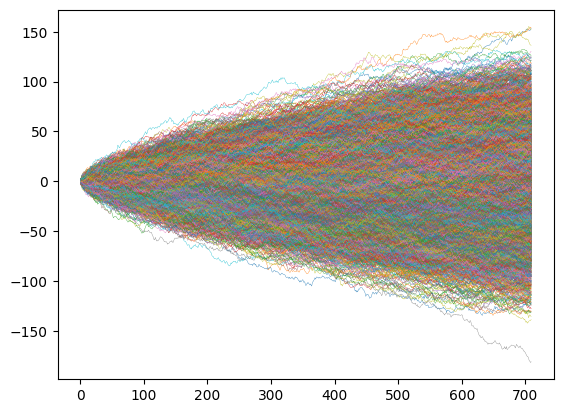

In [10]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.1 # 0.1
bias_par['slope_change'] = 0 # how slope changes from P1 to P2

# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight? 20
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 30 # number of iterations montecarlo
exp_bias = 'lapse_bias'

# if perfect separation error, re-run this code again
params_lapse_bias, params_deci_lapse_bias, simdata_lapse_bias, traces = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)
simdata_lapse_bias.insert(5, 'RepResponses', np.where(simdata_lapse_bias.deci == simdata_lapse_bias.pre_deci, 1, 0))


Merging traces with the simulated data

In [231]:
column_times = list(map(str, np.arange(1, traces.shape[0] + 1))) 
traces_df = pd.DataFrame( traces.transpose(), columns = column_times)

# I have to add the ntrial and nrep columns to the traces_df in the same way as in the simdata_lapse_bias is created
traces_df['ntrial'] = np.tile(np.arange(1, int(traces_df.shape[0]/2) + 1), 2) 
traces_df['nrep'] = np.repeat(np.array([0, 1]), int(traces_df.shape[0]/2))
# now I have to merge the traces_df with the simdata_lapse_bias
merged_sim_data = pd.merge(simdata_lapse_bias, traces_df, on = [ 'nrep', 'ntrial'])

value_vars_as_strings = column_times #[str(i) for i in range(1, traces_df.shape[0] + 1)]
# in long format, the columns are the time points. To facilitate plotting
dflong = pd.melt(merged_sim_data,
                 id_vars=['nrep', 'pre_deci','ntrial', 'DV', 'stim', 'RT', 'deci'],
                 value_vars=value_vars_as_strings, # USE THIS
                 var_name='time',
                 value_name='E')
                 
dflong['time'] = dflong['time'].astype(int) # This is fine, converts '711' string to 711 int


KeyboardInterrupt: 

Example plot of one trace

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_67622/3634857887.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]


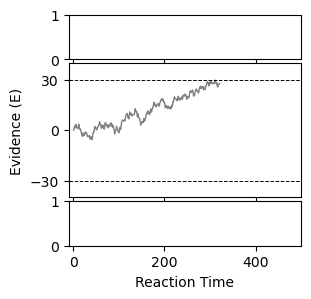

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# --- 1. Filter your data ---
# This is your original filtering for the plot
# We will apply it to both trace data and RT data where applicable.
# The image shows 'dat' as the variable name for the DataFrame.
# Assuming dflong is the comprehensive dataset before this specific plot's filtering.

# Filter for the specific repetition you want to plot (e.g., nrep == 1)
TARGET_NREP = 0 # Change this if you want to plot a different repetition
MAX_NTRIAL = 2 # As in your example

# Data for DDM traces
dat_traces_filtered = dflong[(dflong['nrep'] == TARGET_NREP) & (dflong['ntrial'] ==  10)].copy()

# Data for RT distributions
# We need unique trials for RTs.
# First, filter out rows with missing RTs.
dflong_rt_valid = dflong.dropna(subset=['RT']).copy()

# Select relevant columns and drop duplicates to get one RT per trial
dat_rts_summary = dflong_rt_valid[['ntrial', 'nrep', 'RT', 'deci', 'pre_deci']].drop_duplicates(subset=['ntrial', 'nrep'])

# Apply the same nrep and ntrial filters as for the traces
dat_rts_for_plot = dat_rts_summary[(dat_rts_summary['nrep'] == TARGET_NREP) & (dat_rts_summary['ntrial'] < MAX_NTRIAL)].copy()

# Separate RTs for "up" (deci == 1) and "down" (deci == 0) responses
# Your 'deci' column is 0 or 1, which is perfect.
rts_up = dat_rts_for_plot[dat_rts_for_plot['deci'] == 1]
rts_down = dat_rts_for_plot[dat_rts_for_plot['deci'] == 0]


# --- 2. Create the figure and subplots ---
if dat_traces_filtered.empty:
    print(f"No trace data found for nrep == {TARGET_NREP} and ntrial < {MAX_NTRIAL}. Cannot generate plot.")
else:
    fig = plt.figure(figsize=(3, 3)) # Adjust figsize as needed
    gs = GridSpec(3, 1, height_ratios=[1, 3, 1], hspace=0.05) # hspace for vertical spacing

    ax_rt_up = fig.add_subplot(gs[0])
    ax_ddm = fig.add_subplot(gs[1], sharex=ax_rt_up) # Share x-axis (time for DDM, RT for RT plots)
    ax_rt_down = fig.add_subplot(gs[2], sharex=ax_rt_up)

    # --- 3. Plot RT distribution for "UP" responses (deci == 1) (Top panel) ---
    if not rts_up.empty:
        sns.histplot(data=rts_up, x='RT', hue='pre_deci', multiple="layer", kde=True, ax=ax_rt_up,
                     stat="density", common_norm=False, fill=True, alpha=0.5, element="step", legend=False, palette=colpal3)
        #ax_rt_up.set_title('RT Distribution (Up Responses / deci == 1)')
        ax_rt_up.set_ylabel('Density')
        
        ax_rt_up.tick_params(axis='x', labelbottom=False)
        ax_rt_up.set_yticklabels([])
        ax_rt_up.set_ylim(0, 0.006) # As in your original code
        for spine_loc in ['top', 'right', 'bottom', 'left']:
            ax_rt_up.spines[spine_loc].set_visible(False)
        #ax_rt_up.legend(title='Prev. Deci.', loc='upper left')
    else:
        #ax_rt_up.text(0.5, 0.5, "No 'Up' responses for RT plot", ha='center', va='center', transform=ax_rt_up.transAxes)
        ax_rt_up.tick_params(axis='x', labelbottom=False)


    # --- 4. Plot DDM traces (Middle panel) ---
    # Using 'pre_deci' for hue as in your original relplot
    # Create a color palette for 'pre_deci' values (0.0 and 1.0)
    unique_pre_deci = sorted(dat_traces_filtered['pre_deci'].unique())
    palette = sns.color_palette(n_colors=len(unique_pre_deci))
    palette=colpal3
    pre_deci_to_color = {val: palette[i] for i, val in enumerate(unique_pre_deci)}

    for pre_deci_val, group in dat_traces_filtered.groupby('pre_deci'):
        color = pre_deci_to_color[pre_deci_val]
        # Plot individual trial lines
        for trial_id, trial_data in group.groupby('ntrial'):
            plot_data = trial_data[(trial_data.E < 30) & (trial_data.E > -30)]
            sns.lineplot(x='time', y='E', data=plot_data,
                         color='grey',
                         linewidth=1,  ax=ax_ddm, legend=False)

            ''' # Use this to plot traces with different effects
            plot_data = trial_data.copy()
            #plot_data['E'] = plot_data['E'] + 15    
            plot_data['E'] = plot_data['E'] * 2        
            plot_data = plot_data[(plot_data.E < 30) & (plot_data.E > -30)]
            sns.lineplot(x='time', y='E', data=plot_data,
                         color='darkviolet',
                         linewidth=1,  ax=ax_ddm, legend=False)
            '''
            

    # Add overall legend for DDM traces hue if desired (can be tricky with many lines)
    # For simplicity, we rely on the hue distinction by color.
    # You can create custom legend handles if needed:
    # from matplotlib.lines import Line2D
    # legend_handles_ddm = [Line2D([0], [0], color=pre_deci_to_color[val], lw=2, label=f'pre_deci {val}') for val in unique_pre_deci]
    # ax_ddm.legend(handles=legend_handles_ddm, title="Prev. Deci.", loc="upper right")


    # Add horizontal bound lines
    upper_bound = 30
    lower_bound = -30
    ax_ddm.axhline(y=upper_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.axhline(y=lower_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.set_ylim(-40, 40) # As in your original code
    ax_ddm.set_xlim(-10, 500) # As in your original code
    ax_ddm.set_ylabel('Evidence (E)')
    ax_ddm.tick_params(axis='x', labelbottom=False)
    ax_ddm.set_yticks([-30, 0, 30]) # MODIFICATION: Set specific y-axis ticks


    # --- 5. Plot RT distribution for "DOWN" responses (deci == 0) (Bottom panel) ---
    
    #ax_rt_down.text(0.5, 0.5, "No 'Down' responses for RT plot", ha='center', va='center', transform=ax_rt_down.transAxes)
    ax_rt_down.set_xlabel('Reaction Time')


    # --- 6. Final Adjustments ---
    #fig.suptitle(f"DDM Traces and RT Distributions (nrep = {TARGET_NREP})", fontsize=16, y=0.99)
    # Adjust layout AFTER suptitle to make space for it
    fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]

    plt.show()

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_67622/3634857887.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]


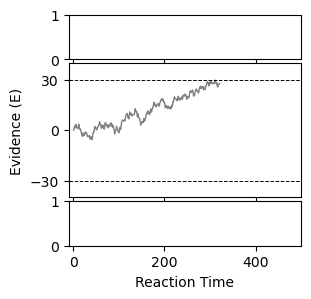

In [228]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# --- 1. Filter your data ---
# This is your original filtering for the plot
# We will apply it to both trace data and RT data where applicable.
# The image shows 'dat' as the variable name for the DataFrame.
# Assuming dflong is the comprehensive dataset before this specific plot's filtering.

# Filter for the specific repetition you want to plot (e.g., nrep == 1)
TARGET_NREP = 0 # Change this if you want to plot a different repetition
MAX_NTRIAL = 2 # As in your example

# Data for DDM traces
dat_traces_filtered = dflong[(dflong['nrep'] == TARGET_NREP) & (dflong['ntrial'] ==  10)].copy()

# Data for RT distributions
# We need unique trials for RTs.
# First, filter out rows with missing RTs.
dflong_rt_valid = dflong.dropna(subset=['RT']).copy()

# Select relevant columns and drop duplicates to get one RT per trial
dat_rts_summary = dflong_rt_valid[['ntrial', 'nrep', 'RT', 'deci', 'pre_deci']].drop_duplicates(subset=['ntrial', 'nrep'])

# Apply the same nrep and ntrial filters as for the traces
dat_rts_for_plot = dat_rts_summary[(dat_rts_summary['nrep'] == TARGET_NREP) & (dat_rts_summary['ntrial'] < MAX_NTRIAL)].copy()

# Separate RTs for "up" (deci == 1) and "down" (deci == 0) responses
# Your 'deci' column is 0 or 1, which is perfect.
rts_up = dat_rts_for_plot[dat_rts_for_plot['deci'] == 1]
rts_down = dat_rts_for_plot[dat_rts_for_plot['deci'] == 0]


# --- 2. Create the figure and subplots ---
if dat_traces_filtered.empty:
    print(f"No trace data found for nrep == {TARGET_NREP} and ntrial < {MAX_NTRIAL}. Cannot generate plot.")
else:
    fig = plt.figure(figsize=(3, 3)) # Adjust figsize as needed
    gs = GridSpec(3, 1, height_ratios=[1, 3, 1], hspace=0.05) # hspace for vertical spacing

    ax_rt_up = fig.add_subplot(gs[0])
    ax_ddm = fig.add_subplot(gs[1], sharex=ax_rt_up) # Share x-axis (time for DDM, RT for RT plots)
    ax_rt_down = fig.add_subplot(gs[2], sharex=ax_rt_up)

    # --- 3. Plot RT distribution for "UP" responses (deci == 1) (Top panel) ---
    if not rts_up.empty:
        sns.histplot(data=rts_up, x='RT', hue='pre_deci', multiple="layer", kde=True, ax=ax_rt_up,
                     stat="density", common_norm=False, fill=True, alpha=0.5, element="step", legend=False, palette=colpal3)
        #ax_rt_up.set_title('RT Distribution (Up Responses / deci == 1)')
        ax_rt_up.set_ylabel('Density')
        
        ax_rt_up.tick_params(axis='x', labelbottom=False)
        ax_rt_up.set_yticklabels([])
        ax_rt_up.set_ylim(0, 0.006) # As in your original code
        for spine_loc in ['top', 'right', 'bottom', 'left']:
            ax_rt_up.spines[spine_loc].set_visible(False)
        #ax_rt_up.legend(title='Prev. Deci.', loc='upper left')
    else:
        #ax_rt_up.text(0.5, 0.5, "No 'Up' responses for RT plot", ha='center', va='center', transform=ax_rt_up.transAxes)
        ax_rt_up.tick_params(axis='x', labelbottom=False)


    # --- 4. Plot DDM traces (Middle panel) ---
    # Using 'pre_deci' for hue as in your original relplot
    # Create a color palette for 'pre_deci' values (0.0 and 1.0)
    unique_pre_deci = sorted(dat_traces_filtered['pre_deci'].unique())
    palette = sns.color_palette(n_colors=len(unique_pre_deci))
    palette=colpal3
    pre_deci_to_color = {val: palette[i] for i, val in enumerate(unique_pre_deci)}

    for pre_deci_val, group in dat_traces_filtered.groupby('pre_deci'):
        color = pre_deci_to_color[pre_deci_val]
        # Plot individual trial lines
        for trial_id, trial_data in group.groupby('ntrial'):
            plot_data = trial_data[(trial_data.E < 30) & (trial_data.E > -30)]
            sns.lineplot(x='time', y='E', data=plot_data,
                         color='grey',
                         linewidth=1,  ax=ax_ddm, legend=False)

            ''' # Use this to plot traces with different effects
            plot_data = trial_data.copy()
            #plot_data['E'] = plot_data['E'] + 15    
            plot_data['E'] = plot_data['E'] * 2        
            plot_data = plot_data[(plot_data.E < 30) & (plot_data.E > -30)]
            sns.lineplot(x='time', y='E', data=plot_data,
                         color='darkviolet',
                         linewidth=1,  ax=ax_ddm, legend=False)
            '''
            

    # Add overall legend for DDM traces hue if desired (can be tricky with many lines)
    # For simplicity, we rely on the hue distinction by color.
    # You can create custom legend handles if needed:
    # from matplotlib.lines import Line2D
    # legend_handles_ddm = [Line2D([0], [0], color=pre_deci_to_color[val], lw=2, label=f'pre_deci {val}') for val in unique_pre_deci]
    # ax_ddm.legend(handles=legend_handles_ddm, title="Prev. Deci.", loc="upper right")


    # Add horizontal bound lines
    upper_bound = 30
    lower_bound = -30
    ax_ddm.axhline(y=upper_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.axhline(y=lower_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.set_ylim(-40, 40) # As in your original code
    ax_ddm.set_xlim(-10, 500) # As in your original code
    ax_ddm.set_ylabel('Evidence (E)')
    ax_ddm.tick_params(axis='x', labelbottom=False)
    ax_ddm.set_yticks([-30, 0, 30]) # MODIFICATION: Set specific y-axis ticks


    # --- 5. Plot RT distribution for "DOWN" responses (deci == 0) (Bottom panel) ---
    
    #ax_rt_down.text(0.5, 0.5, "No 'Down' responses for RT plot", ha='center', va='center', transform=ax_rt_down.transAxes)
    ax_rt_down.set_xlabel('Reaction Time')


    # --- 6. Final Adjustments ---
    #fig.suptitle(f"DDM Traces and RT Distributions (nrep = {TARGET_NREP})", fontsize=16, y=0.99)
    # Adjust layout AFTER suptitle to make space for it
    fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]

    plt.show()

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_67622/3740575129.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]


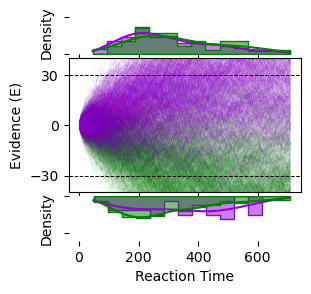

In [201]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# --- 1. Filter your data ---
# This is your original filtering for the plot
# We will apply it to both trace data and RT data where applicable.
# The image shows 'dat' as the variable name for the DataFrame.
# Assuming dflong is the comprehensive dataset before this specific plot's filtering.

# Filter for the specific repetition you want to plot (e.g., nrep == 1)
TARGET_NREP = 1 # Change this if you want to plot a different repetition
MAX_NTRIAL = 1500 # As in your example

# Data for DDM traces
dat_traces_filtered = dflong[(dflong['nrep'] == TARGET_NREP) & (dflong['ntrial'] < MAX_NTRIAL)].copy()

# Data for RT distributions
# We need unique trials for RTs.
# First, filter out rows with missing RTs.
dflong_rt_valid = dflong.dropna(subset=['RT']).copy()

# Select relevant columns and drop duplicates to get one RT per trial
dat_rts_summary = dflong_rt_valid[['ntrial', 'nrep', 'RT', 'deci', 'pre_deci']].drop_duplicates(subset=['ntrial', 'nrep'])

# Apply the same nrep and ntrial filters as for the traces
dat_rts_for_plot = dat_rts_summary[(dat_rts_summary['nrep'] == TARGET_NREP) & (dat_rts_summary['ntrial'] < MAX_NTRIAL)].copy()

# Separate RTs for "up" (deci == 1) and "down" (deci == 0) responses
# Your 'deci' column is 0 or 1, which is perfect.
rts_up = dat_rts_for_plot[dat_rts_for_plot['deci'] == 1]
rts_down = dat_rts_for_plot[dat_rts_for_plot['deci'] == 0]


# --- 2. Create the figure and subplots ---
if dat_traces_filtered.empty:
    print(f"No trace data found for nrep == {TARGET_NREP} and ntrial < {MAX_NTRIAL}. Cannot generate plot.")
else:
    fig = plt.figure(figsize=(3, 3)) # Adjust figsize as needed
    gs = GridSpec(3, 1, height_ratios=[1, 3, 1], hspace=0.05) # hspace for vertical spacing

    ax_rt_up = fig.add_subplot(gs[0])
    ax_ddm = fig.add_subplot(gs[1], sharex=ax_rt_up) # Share x-axis (time for DDM, RT for RT plots)
    ax_rt_down = fig.add_subplot(gs[2], sharex=ax_rt_up)

    # --- 3. Plot RT distribution for "UP" responses (deci == 1) (Top panel) ---
    if not rts_up.empty:
        sns.histplot(data=rts_up, x='RT', hue='pre_deci', multiple="layer", kde=True, ax=ax_rt_up,
                     stat="density", common_norm=False, fill=True, alpha=0.5, element="step", legend=False, palette=colpal3)
        #ax_rt_up.set_title('RT Distribution (Up Responses / deci == 1)')
        ax_rt_up.set_ylabel('Density')
        
        ax_rt_up.tick_params(axis='x', labelbottom=False)
        ax_rt_up.set_yticklabels([])
        ax_rt_up.set_ylim(0, 0.006) # As in your original code
        for spine_loc in ['top', 'right', 'bottom', 'left']:
            ax_rt_up.spines[spine_loc].set_visible(False)
        #ax_rt_up.legend(title='Prev. Deci.', loc='upper left')
    else:
        ax_rt_up.text(0.5, 0.5, "No 'Up' responses for RT plot", ha='center', va='center', transform=ax_rt_up.transAxes)
        ax_rt_up.tick_params(axis='x', labelbottom=False)


    # --- 4. Plot DDM traces (Middle panel) ---
    # Using 'pre_deci' for hue as in your original relplot
    # Create a color palette for 'pre_deci' values (0.0 and 1.0)
    unique_pre_deci = sorted(dat_traces_filtered['pre_deci'].unique())
    palette = sns.color_palette(n_colors=len(unique_pre_deci))
    palette=colpal3
    pre_deci_to_color = {val: palette[i] for i, val in enumerate(unique_pre_deci)}

    for pre_deci_val, group in dat_traces_filtered.groupby('pre_deci'):
        color = pre_deci_to_color[pre_deci_val]
        # Plot individual trial lines
        for trial_id, trial_data in group.groupby('ntrial'):
            sns.lineplot(x='time', y='E', data=trial_data,
                         color=color,
                         linewidth=0.1, alpha=0.2, ax=ax_ddm, legend=False)

    # Add overall legend for DDM traces hue if desired (can be tricky with many lines)
    # For simplicity, we rely on the hue distinction by color.
    # You can create custom legend handles if needed:
    # from matplotlib.lines import Line2D
    # legend_handles_ddm = [Line2D([0], [0], color=pre_deci_to_color[val], lw=2, label=f'pre_deci {val}') for val in unique_pre_deci]
    # ax_ddm.legend(handles=legend_handles_ddm, title="Prev. Deci.", loc="upper right")


    # Add horizontal bound lines
    upper_bound = 30
    lower_bound = -30
    ax_ddm.axhline(y=upper_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.axhline(y=lower_bound, color='black', linestyle='--', linewidth=0.7)
    ax_ddm.set_ylim(-40, 40) # As in your original code
    ax_ddm.set_ylabel('Evidence (E)')
    ax_ddm.tick_params(axis='x', labelbottom=False)
    ax_ddm.set_yticks([-30, 0, 30]) # MODIFICATION: Set specific y-axis ticks


    # --- 5. Plot RT distribution for "DOWN" responses (deci == 0) (Bottom panel) ---
    if not rts_down.empty:
        sns.histplot(data=rts_down, x='RT', hue='pre_deci', multiple="layer", kde=True, ax=ax_rt_down,
                     stat="density", common_norm=False, fill=True, alpha=0.5, element="step",legend=False, palette=colpal3)
        # ax_rt_down.set_title('RT Distribution (Down Responses / deci == 0)') # Title optional
        ax_rt_down.set_xlabel('Reaction Time') # X-axis units depend on your RT scale (ms in image)
        ax_rt_down.set_ylabel('Density')
        #ax_rt_down.legend(title='Prev. Deci.', loc='upper right')
        ax_rt_down.set_ylim(0, 0.006) # As in your original code
        ax_rt_down.invert_yaxis()
        ax_rt_down.set_yticklabels([])
        for spine_loc in ['top', 'right',  'left', 'bottom']:
            ax_rt_down.spines[spine_loc].set_visible(False)
    else:
        ax_rt_down.text(0.5, 0.5, "No 'Down' responses for RT plot", ha='center', va='center', transform=ax_rt_down.transAxes)
        ax_rt_down.set_xlabel('Reaction Time')


    # --- 6. Final Adjustments ---
    #fig.suptitle(f"DDM Traces and RT Distributions (nrep = {TARGET_NREP})", fontsize=16, y=0.99)
    # Adjust layout AFTER suptitle to make space for it
    fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # rect=[left, bottom, right, top]

    plt.show()

In [191]:
def compute_condbias(x):
    rt_series = x['RT']

    # Remove or replace zero/negative RTs
    #rt_series = rt_series.clip(lower=1e-5)

    #log_rt = np.log(rt_series)
    #max_log_rt = log_rt.max()
    #transformed_rt = max_log_rt - log_rt

    transformed_rt = rt_series.copy()
    # Handle case where std is zero
    if transformed_rt.std() == 0:
        zRT = pd.Series(0, index=x.index)
    else:
        zRT = (transformed_rt - transformed_rt.mean()) / transformed_rt.std()

    x = x.copy()  # Avoid SettingWithCopyWarning
    x['zRT'] = zRT

    # Bin using qcut with error handling for duplicate edges
    try:
        x['qs'] = pd.qcut(x['zRT'], q=[0, 0.15, 0.3, 0.5, 0.7, 0.9, 1], labels=False, duplicates='drop')
    except ValueError:
        x['qs'] = np.nan  # or set a default value / bin

    return x

# Apply to groups

In [242]:
#dat = simdata_lapse_bias.copy()
dat = simdata_lapse_bias.copy()
dat = dat.groupby(['nrep'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nrep','qs','pre_deci'],as_index=False)['deci'].mean()
outmean.loc[outmean['nrep'] == 0, 'pre_deci'] = 3.0 # Use a float if original is float


/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_67622/3290126852.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dat = dat.groupby(['nrep'], group_keys=False).apply(compute_condbias).reset_index(drop=True)


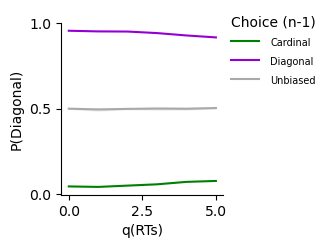

In [243]:

# Create the plot
g = sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
   kind="line", palette=colpal3a, aspect=1, height=2.5
)

# --- Modifications for x-axis ticks and label ---
# Set specific x-axis tick marks
g.set(xticks=[0, 2.5, 5])
g.set(yticks=[0, 0.5, 1])

# Set the x-axis label with a small font size
# Iterate over the axes in the FacetGrid (though for a single plot, there's one)
for ax in g.axes.flat:
    ax.set_xlabel("q(RTs)", fontsize=10) # 'small', 'x-small', or a specific number like 8 or 10
    ax.set_ylabel("P(Diagonal)", fontsize=10) # 'small', 'x-small', or a specific number like 8 or 10

if g._legend:
    # Set the legend title
    g._legend.set_title("N-1 Choice")
    
    legend_handles = g._legend.legendHandles if hasattr(g._legend, 'legendHandles') else g._legend.legend_handles # older vs newer matplotlib
    current_labels_from_handles = [handle.get_label() for handle in legend_handles]
    
    # Option 1: If you know the exact order of hue categories in the legend
    # (Often sorted numerically/alphabetically by default)
    # Example: if pre_deci values 0.0, 1.0, 3.0 map to legend entries in that order:
    new_labels = ['Cardinal', 'Diagonal', 'Unbiased'] # Check this order!

    # Option 2: More robust mapping if pre_deci values are known
    # This requires knowing what your `pre_deci` values are.
    # Let's say your unique `pre_deci` values used for hue are [0.0, 1.0, 3.0]
    # and they appear in the legend in this sorted order.
    
    label_mapping = {
        # Convert pre_deci values to string as they appear in legend texts if they are numeric
        str(float(0.0)): 'Cardinal', # Assuming pre_deci was 0.0
        str(float(1.0)): 'Diagonal', # Assuming pre_deci was 1.0
        str(float(3.0)): 'Unbiased'  # The value you set for nrep==0
    }

    if len(g._legend.texts) == len(new_labels): # Basic check
         for i, text_obj in enumerate(g._legend.texts):
            original_label_text = text_obj.get_text()
            # Try to map, fallback to predefined order if direct map fails
            if original_label_text in label_mapping:
                text_obj.set_text(label_mapping[original_label_text])
            elif i < len(new_labels): # Fallback to ordered list if key not found
                 print(f"Warning: Label '{original_label_text}' not in mapping, using ordered label '{new_labels[i]}'. Check label_mapping keys.")
                 text_obj.set_text(new_labels[i])
            else:
                print(f"Warning: More legend texts than new labels. Skipping text for '{original_label_text}'.")

    else:
        print(f"Warning: Number of legend texts ({len(g._legend.texts)}) does not match number of new labels ({len(new_labels)}). Legend labels not fully updated.")
        # As a simpler fallback if the mapping is tricky:
        # if len(g._legend.texts) == 3: # If you are sure there are 3 items
        #    g._legend.texts[0].set_text('Cardinal')
        #    g._legend.texts[1].set_text('Diagonal')
        #    g._legend.texts[2].set_text('Unbiased')
    sns.move_legend(
        g, "upper right",
        bbox_to_anchor=(1.1, 1), # Optional: fine-tune position (relative to loc)
        # title=g._legend.get_title().get_text(), # Preserve the title
        # frameon=True # Optional: add a frame
    )
    # Re-apply title and font size as move_legend might recreate it
    if g._legend: # Check if legend still exists after move_legend
        g._legend.set_title("Choice (n-1)")
        plt.setp(g._legend.get_title(), fontsize=10)
        for text_obj in g._legend.texts:
            text_obj.set_fontsize(7)

    

    # Adjust legend properties if needed (e.g., font size of title)
    plt.setp(g._legend.get_title(), fontsize=10) # Adjust title font size


#figpath = os.path.join(figures_path, 'RTs_simZ.pdf')
figpath = os.path.join(figures_path, 'RTs_simDC.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


In [ ]:
sns.relplot(
   data=outmean, x="qs", y="RepResponses", hue="nrep",
    kind="line",  palette= colpal2, aspect=1.5, height=1.75,
)

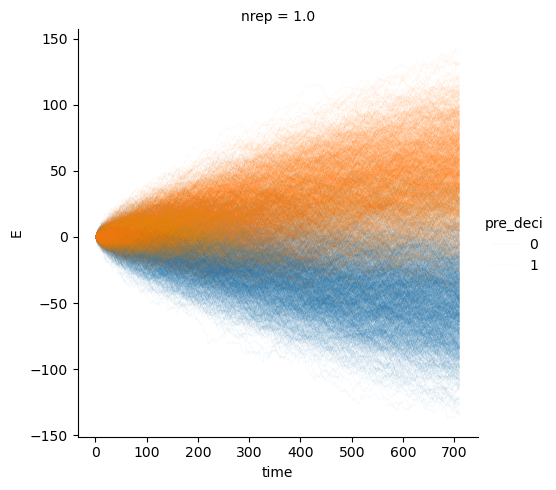

In [43]:
dat = dflong[(dflong.nrep == 1) & (dflong.ntrial < 3000)]
sns.relplot(data=dat, x='time', y='E', col='nrep', hue='pre_deci', kind="line", units = 'ntrial', estimator=None, linewidth=0.1, alpha = 0.2)

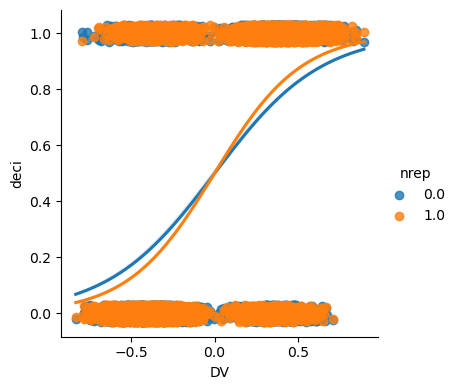

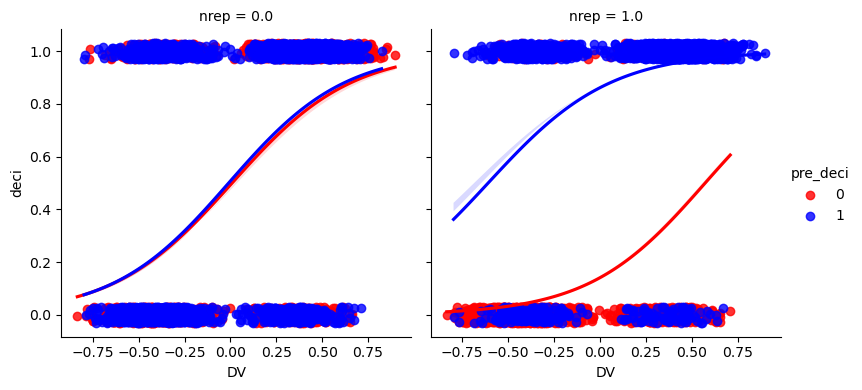

In [24]:
sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=2
)


sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=2, 
    hue_order = [0,1],palette=['red','blue']
)

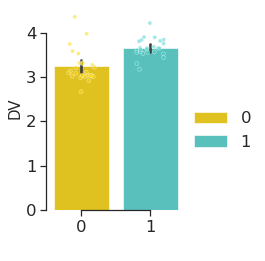

In [ ]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_lapse_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


In [ ]:
all_sim_data

,stim,nrep,DV,pre_deci,deci,RT,ntrial,nit,exp_bias,1,...,701,702,703,704,705,706,707,708,709,710
0,1.0,0.0,0.360074,0,1,172.0,1,0,lapse_bias,0.0,...,20.737689,20.802898,19.811344,20.531634,20.164830,20.766058,22.863897,21.302974,20.149563,18.566791
1,1.0,1.0,0.360074,1,1,453.0,2,0,lapse_bias,0.0,...,10.606546,9.571396,7.050488,6.372668,7.075861,5.404521,5.839467,9.014829,7.753409,7.933609
2,1.0,0.0,0.289230,1,1,NaN,3,0,lapse_bias,0.0,...,-19.220401,-20.818112,-19.513486,-19.856609,-17.916372,-17.094038,-17.790339,-18.151587,-19.332703,-19.990880
3,1.0,1.0,0.289230,1,1,NaN,4,0,lapse_bias,0.0,...,33.764485,34.089982,35.459882,35.809477,33.354566,33.839656,34.331611,34.565444,34.964034,34.664620
4,-1.0,0.0,-0.300342,0,0,367.0,5,0,lapse_bias,0.0,...,4.354159,4.712339,4.255399,6.896652,6.053641,6.521099,5.586675,6.748381,8.109414,7.304916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,1.0,0.428222,1,1,170.0,9996,0,lapse_bias,-0.0,...,-31.643280,-28.871839,-28.693310,-30.013178,-30.369631,-29.592565,-30.270714,-31.432138,-32.032425,-31.833849
9996,1.0,0.0,0.464212,0,1,203.0,9997,0,lapse_bias,-0.0,...,-20.094240,-20.491849,-20.709293,-20.354375,-21.406460,-20.146801,-21.320635,-21.490176,-23.645411,-22.512856
9997,1.0,1.0,0.464212,1,1,254.0,9998,0,lapse_bias,0.0,...,62.219781,60.679229,61.847912,62.074885,64.141628,64.668832,63.814295,60.302125,61.813359,61.264602
9998,-1.0,0.0,-0.462308,0,1,NaN,9999,0,lapse_bias,0.0,...,94.581791,94.907283,95.611854,95.863513,96.212679,96.444027,95.356281,94.670537,95.221656,97.563918


In [18]:
np.shape(simdata_lapse_bias)

(10000, 9)

In [13]:
simdata_lapse_bias

,stim,nrep,DV,pre_deci,deci,RT,ntrial,nit,exp_bias
0,1.0,0.0,0.347854,1,1,369.0,1,0,lapse_bias
1,1.0,1.0,0.347854,1,1,425.0,2,0,lapse_bias
2,1.0,0.0,0.439666,1,1,528.0,3,0,lapse_bias
3,1.0,1.0,0.439666,1,1,348.0,4,0,lapse_bias
4,-1.0,0.0,-0.571684,1,0,319.0,5,0,lapse_bias
...,...,...,...,...,...,...,...,...,...
9995,1.0,1.0,0.250885,1,1,100.0,9996,0,lapse_bias
9996,1.0,0.0,0.304565,0,1,333.0,9997,0,lapse_bias
9997,1.0,1.0,0.304565,1,1,241.0,9998,0,lapse_bias
9998,1.0,0.0,0.415473,0,1,463.0,9999,0,lapse_bias


__Simulate one experiment traces for plotting__

sim_df, sim_data =  create_exp() # regenerate the simulated experiment in each iteration
outsim_df, E = sim_ddm(sim_data, sim_df, obs_knel, bias_par, ddm_par, stim_par)
plt.plot(E[:,0:20], lw = 0.25)

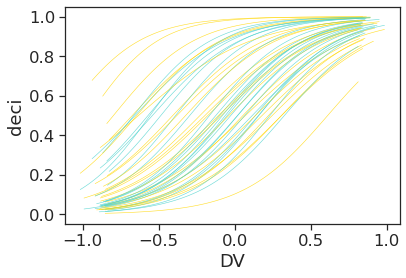

In [ ]:

for i in np.arange(0,24):
    dat2=simdata_lapse_bias[(simdata_lapse_bias.nit == i)]
    for cell in [0,1]:
        sns.regplot(x="DV", y="deci",  data=dat2.loc[dat2.nrep == cell,:],
           logistic=True, y_jitter=0, scatter_kws={'alpha':0}, ci=True, n_boot=1,  label=cell,  truncate=True, 
                         line_kws ={'alpha':0.8, 'lw':0.6}, color = colpal2[cell]); #mean all subject


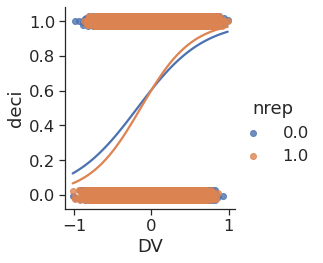

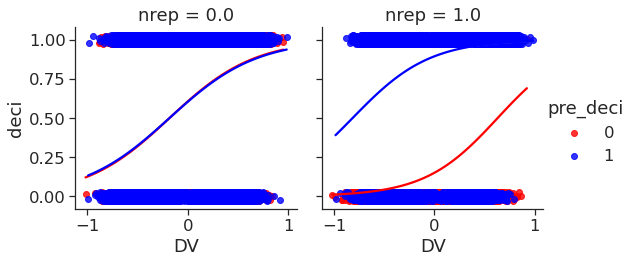

In [ ]:
sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=2
)


sns.lmplot(
    data=simdata_lapse_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=2, 
    hue_order = [0,1],palette=['red','blue']
)

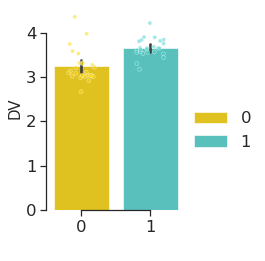

In [ ]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_lapse_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


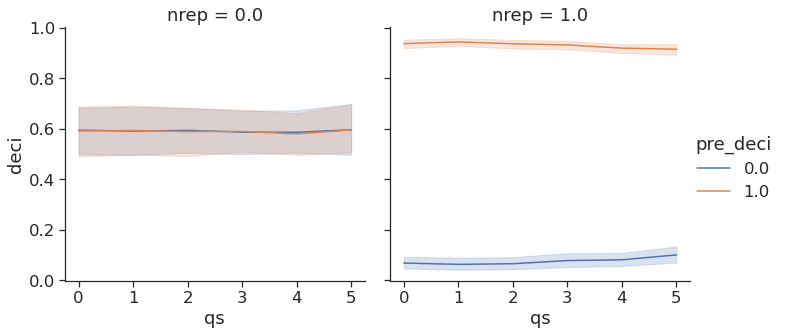

In [ ]:
#dat = simdata_lapse_bias.copy()
dat = simdata_lapse_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

In [ ]:
 params_deci_lapse_bias

,niter,nrep,pre_deci,model,intercept,DV
0,0,0,0,lapse_bias,0.368563,3.275941
1,0,0,1,lapse_bias,0.304793,3.094255
2,0,1,0,lapse_bias,-1.807343,2.921397
3,0,1,1,lapse_bias,2.381528,3.397355
4,1,0,0,lapse_bias,0.271791,3.158301
5,1,0,1,lapse_bias,0.252670,3.046342
6,1,1,0,lapse_bias,-1.776150,3.064988
7,1,1,1,lapse_bias,2.436711,3.255955


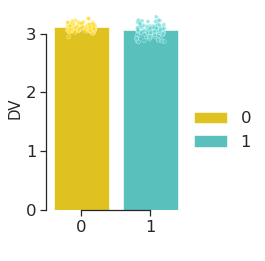

In [ ]:
params_avgdeci_lapse_bias = params_deci_lapse_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_lapse_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


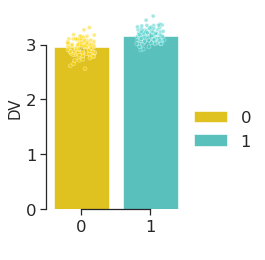

In [ ]:


dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_lapse_bias[params_deci_lapse_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Selective bias model (slope model)

this model assumes that sensitivity changes dynamically with the distance of the sample to the previous choice. This model is esentially the same as the lapse model although a bit more complex

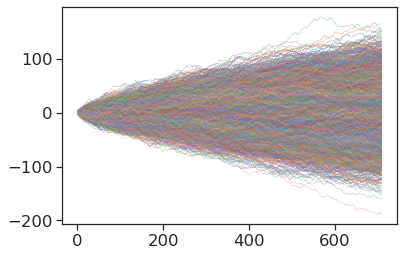

In [ ]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.1
bias_par['slope_change'] = 1 # how slope changes from P1 to P2 [if you increase a lot of the slope, the model will not show the reduction in slope

# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo
exp_bias = 'sensitivity_bias'

params_sensi_bias, params_deci_sensi_bias, simdata_sensi_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)


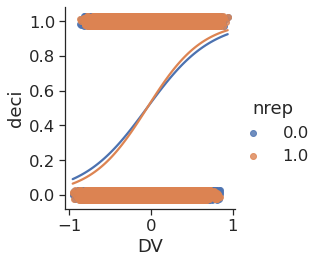

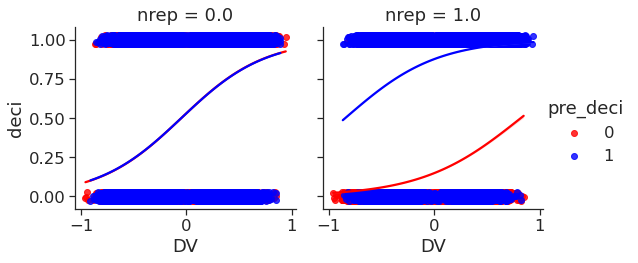

In [ ]:
sns.lmplot(
    data=simdata_sensi_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=2
)



sns.lmplot(
    data=simdata_sensi_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=2, 
    hue_order = [0,1],palette=['red','blue']
)

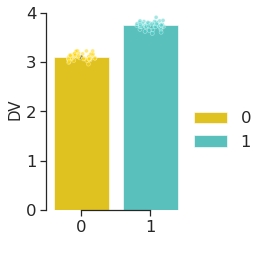

In [ ]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_sensi_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


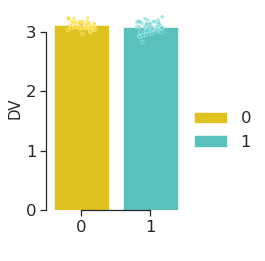

In [ ]:
params_avgdeci_sensi_bias = params_deci_sensi_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_sensi_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


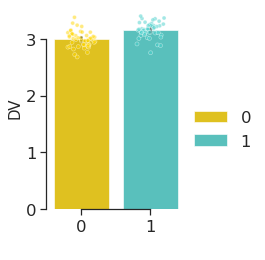

In [ ]:


dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_sensi_bias[params_deci_sensi_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Non selective bias model (threshold model)

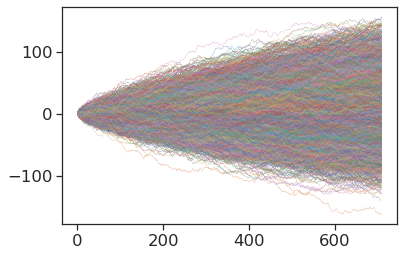

In [ ]:

# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.15
bias_par['slope_val_bias'] = 0
bias_par['lapse_bias'] = 0.0
bias_par['slope_change'] = 0 # how slope changes from P1 to P2


# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 0 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo
exp_bias = 'threshold_bias'


params_threshold_bias, params_deci_threshold_bias, simdata_threshold_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)


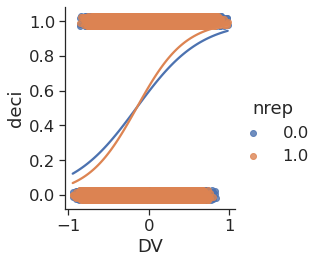

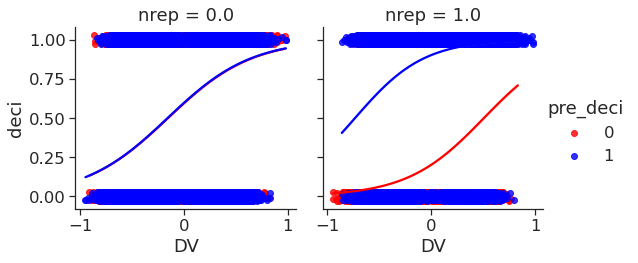

In [ ]:
sns.lmplot(
    data=simdata_threshold_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=10
)



sns.lmplot(
    data=simdata_threshold_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=10, 
    hue_order = [0,1],palette=['red','blue']
)

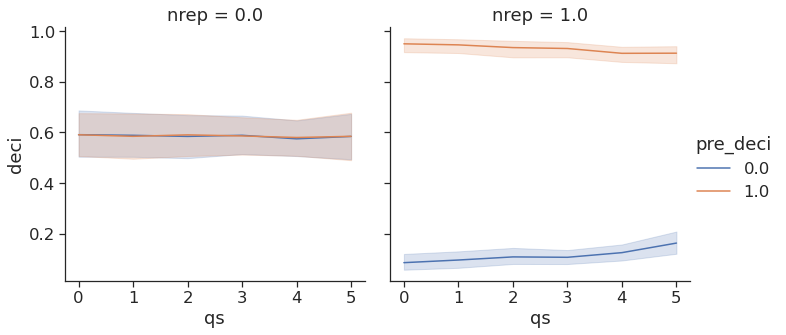

In [ ]:
#dat = simdata_lapse_bias.copy()
dat = simdata_threshold_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

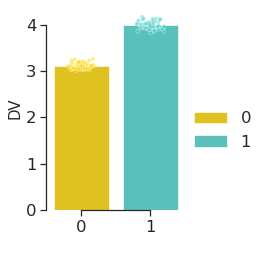

In [ ]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_threshold_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


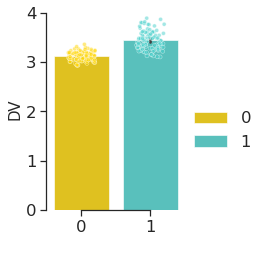

In [ ]:
params_avgdeci_threshold_bias = params_deci_threshold_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_threshold_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


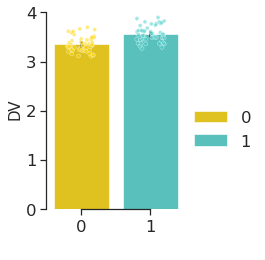

In [ ]:
dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_threshold_bias[params_deci_threshold_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


## Z model

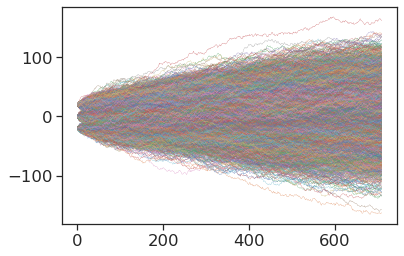

In [ ]:
# Bias parameters_coefs
bias_par = {}
bias_par['threshold_bias'] = 0.0
bias_par['slope_val_bias'] = 0.0
bias_par['lapse_bias'] = 0.0
bias_par['slope_change'] = 0 # how slope changes from P1 to P2


# DDM parameters (DV is given by participants psychometric function and the stimulus)
ddm_par = {}
ddm_par['p_t'] = 10 # non-decision time
ddm_par['p_z'] = 20 # prior weight?
ddm_par['p_c'] = 0.0
ddm_par['bound'] = 30 # boundary separation

# stimuli noise parameters
stim_par = {}
stim_par['mu'] = 0
stim_par['sigma'] = 1
    
nits = 25 # number of iterations montecarlo

exp_bias = 'Z_bias'


params_Z_bias, params_deci_Z_bias, simdata_Z_bias = simulate_it(nits,bias_par,ddm_par,stim_par, exp_bias, obs_knel)
    

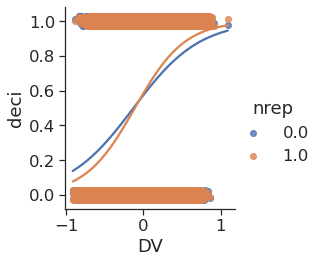

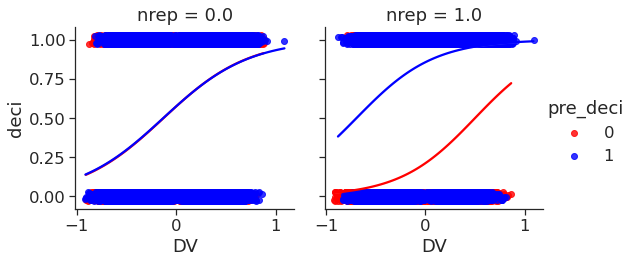

In [ ]:
sns.lmplot(
    data=simdata_Z_bias, x="DV", y="deci",
    hue="nrep", height=4, logistic=True, y_jitter=.03, n_boot=10
)



sns.lmplot(
    data=simdata_Z_bias, x="DV", y="deci",
    hue="pre_deci", col = 'nrep' , height=4, logistic=True, y_jitter=.03, n_boot=10, 
    hue_order = [0,1],palette=['red','blue']
)

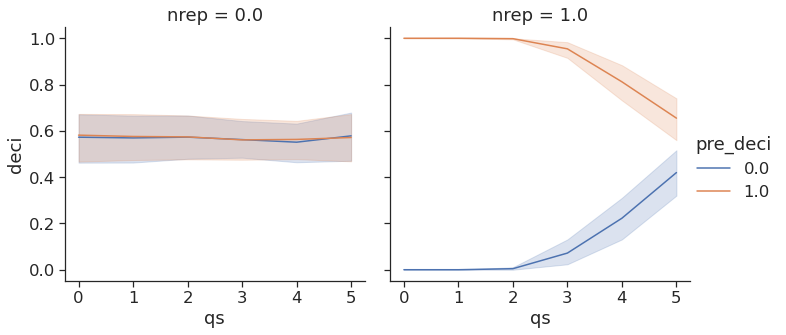

In [ ]:
#dat = simdata_lapse_bias.copy()
dat = simdata_Z_bias.copy()
dat = dat.groupby(['nit', 'nrep','pre_deci'], group_keys=False).apply(compute_condbias).reset_index(drop=True)
outmean = dat.groupby(['nit','nrep','pre_deci','qs'],as_index=False)['deci'].mean()

sns.relplot(
   data=outmean, x="qs", y="deci", hue="pre_deci",
    kind="line", col = 'nrep'
)

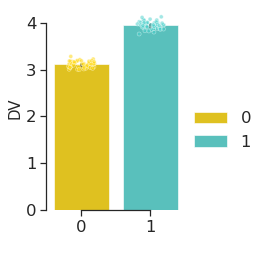

In [ ]:
dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_Z_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


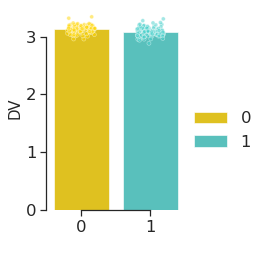

In [ ]:

params_avgdeci_slope_bias = params_deci_slope_bias.groupby(['niter', 'nrep', 'model'],as_index=False)[['intercept','DV']].mean()

dx = 'nrep'; dy = 'DV'; hue = 'nrep';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_avgdeci_slope_bias, dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


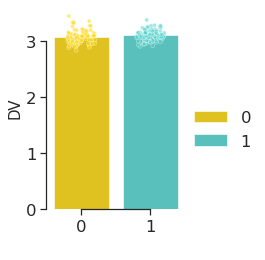

In [ ]:
dx = 'pre_deci'; dy = 'DV'; hue = 'pre_deci';  row = None; col = None
colpal2 = ['gold','mediumturquoise','darkblue']
sizeplot = {}; sizeplot['height'] = 4; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= dy
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
pal = colpal2

barsplot(params_deci_slope_bias[params_deci_slope_bias.nrep == 1], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = False)


In [356]:
 rep0_choices

,original_trial_id,iteration,rep0_decision_01
0,0,0,0
2,1,0,0
4,2,0,0
6,3,0,0
8,4,0,1
...,...,...,...
390,95,1,0
392,96,1,0
394,97,1,0
396,98,1,0


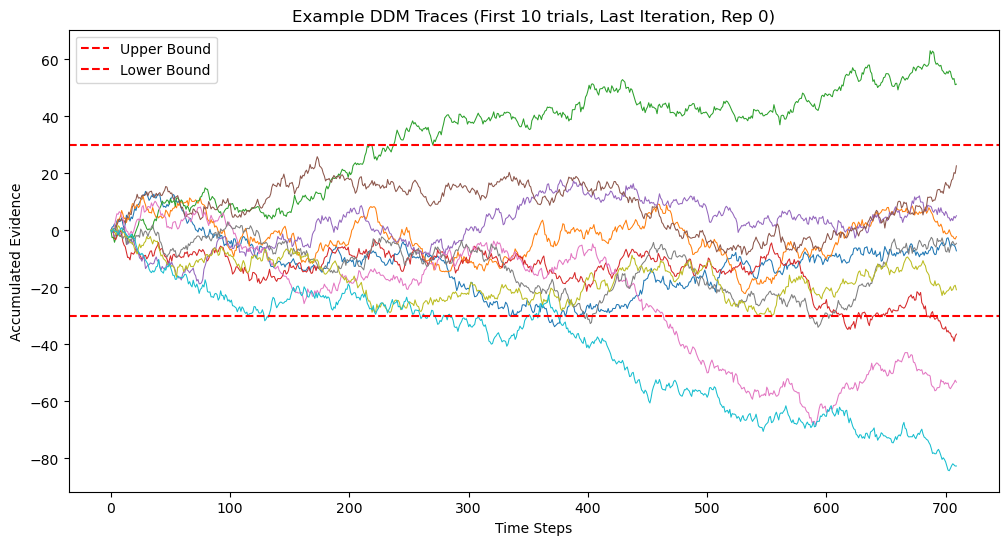

In [380]:
 #     print("\nPlotting example DDM traces from the last iteration, first repetition...")
traces_to_plot = example_ddm_traces[0] # Traces from the first repetition of the last iteration
num_traces_to_show = min(10, traces_to_plot.shape[0]) # Plot up to 10 traces
        
plt.figure(figsize=(12, 6))
plt.plot(traces_to_plot[:, :num_traces_to_show], lw=0.75)
plt.axhline(ddm_params_config['bound_threshold'], color='r', linestyle='--', label='Upper Bound')
plt.axhline(-ddm_params_config['bound_threshold'], color='r', linestyle='--', label='Lower Bound')
plt.title(f"Example DDM Traces (First {num_traces_to_show} trials, Last Iteration, Rep 0)")
plt.xlabel("Time Steps")
plt.ylabel("Accumulated Evidence")
plt.legend()
plt.show()

In [349]:
 glm_overall_results

,iteration,experiment_tag,repetition_n,intercept,beta_mean_stim_energy
0,0,example_run_bias_test,0,-1.567257,3.984706
1,0,example_run_bias_test,1,-1.872329,4.861241
2,1,example_run_bias_test,0,-1.441605,3.853201
3,1,example_run_bias_test,1,-1.923125,5.063445


Starting simulations with refined bias logic...

--- Simulation Summary Data (first 5 rows) ---
   stim_orientation  repetition_n  mean_stim_energy_dv  \
0                -1             0            -0.471124   
1                -1             1            -0.471124   
2                -1             0            -0.216230   
3                -1             1            -0.216230   
4                 1             0             0.249067   

   conditioning_prev_choice_01  decision_01  reaction_time  original_trial_id  \
0                            0            0          300.0                  0   
1                            0            0          695.0                  0   
2                            1            0          179.0                  1   
3                            0            0          456.0                  1   
4                            1            0          710.0                  2   

   iteration      experiment_tag  
0          0  rep_bias_test_plot 

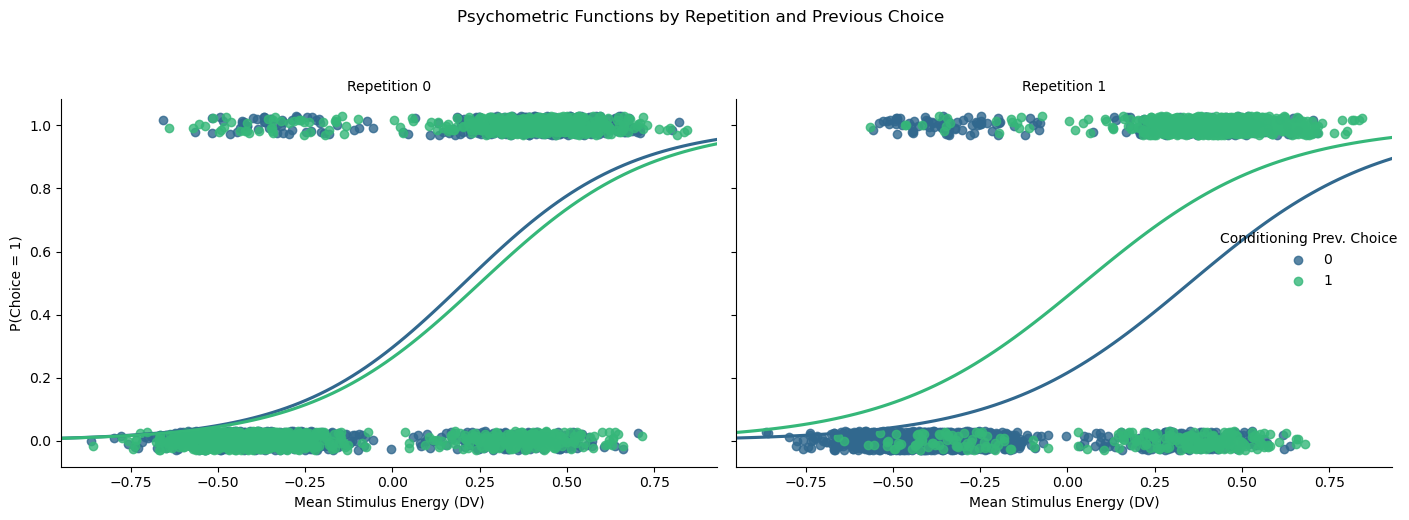


Consistency check (Rep1 'conditioning_prev_choice' == actual Rep0 decision): True

--- Cross-tab: Actual Rep0 Choice vs Rep1 Choice (first iteration) ---
Rep1 Choice           0    1
Actual Rep0 Choice          
0                   261   62
1                    41  136


In [378]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns # Import seaborn

# --- (Keep all your existing functions: DEFAULT_NTRIALS, z_score_scaling, psychometric_function, etc.) ---
# ...
# --- (DEFAULT_NTRIALS, DEFAULT_TSTIM_SERIES, ..., apply_decision_bound) ---
# ...
# --- (simulate_trials_with_history, fit_glm_and_extract_params, run_full_simulation_and_analysis) ---
# ...

# --- Constants ---
DEFAULT_NTRIALS = 500 
DEFAULT_TSTIM_SERIES = 500
DEFAULT_TNOSTIM_SERIES = 200
DEFAULT_STIM_STRENGTH = 0.4
DEFAULT_STIM_VARIANCE = 3.0
DEFAULT_NREPS = 2

DEFAULT_DDM_NON_DECISION_TIME = 10
DEFAULT_DDM_STARTING_BIAS_WEIGHT_CONFIG = 0.0
DEFAULT_DDM_DRIFT_CRITERION_COEFF_CONFIG = 0.0 
DEFAULT_DDM_BOUND = 30.0

DEFAULT_STIM_NOISE_MEAN = 0.0
DEFAULT_STIM_NOISE_SIGMA = 1.0

MAP_01_TO_PM_ONE = {0: -1.0, 1: 1.0} 
MAP_PM_ONE_TO_01 = {-1.0: 0, 1.0: 1}

# --- Helper Functions ---
def z_score_scaling(matrix: np.ndarray) -> np.ndarray:
    mean_val = np.mean(matrix)
    std_val = np.std(matrix)
    if std_val == 0:
        return matrix - mean_val
    return (matrix - mean_val) / std_val

def psychometric_function(
    x: np.ndarray, threshold: float, slope: float, lapse_low: float, lapse_high: float
) -> np.ndarray:
    return lapse_low + (1 - lapse_low - lapse_high) * \
           (1 / (1 + np.exp(-slope * (x - threshold))))

def decimetric_probabilities( 
    x: np.ndarray, threshold: np.ndarray, slope: np.ndarray, 
    lapse_low: np.ndarray, lapse_high: np.ndarray
) -> np.ndarray:
    return lapse_low + (1 - lapse_low - lapse_high) * \
           (1 / (1 + np.exp(-slope * (x - threshold))))

# --- Core Simulation Functions ---

def create_experimental_data(
    num_trials: int = DEFAULT_NTRIALS,
    stim_duration: int = DEFAULT_TSTIM_SERIES,
    no_stim_duration: int = DEFAULT_TNOSTIM_SERIES,
    stim_strength: float = DEFAULT_STIM_STRENGTH,
    stim_variance: float = DEFAULT_STIM_VARIANCE,
    num_reps: int = DEFAULT_NREPS
) -> tuple[pd.DataFrame, np.ndarray]:
    stim_data = np.random.normal(stim_strength, stim_variance, (num_trials, stim_duration))
    stim_orientation_vector = np.random.choice([-1, 1], size=stim_data.shape[0])
    stim_data *= stim_orientation_vector[:, np.newaxis]
    stim_data_repeated = np.repeat(stim_data, num_reps, axis=0)
    
    mean_stim_energy_original = np.mean(stim_data, axis=1)
    mean_stim_energy_for_df = np.repeat(mean_stim_energy_original, num_reps, axis=0)

    nostim_data = np.random.normal(0, stim_variance, (num_trials * num_reps, no_stim_duration))
    simulated_traces = np.concatenate((stim_data_repeated, nostim_data), axis=1)
    simulated_traces_scaled = z_score_scaling(simulated_traces)

    stim_orientation_repeated = np.repeat(stim_orientation_vector, num_reps, axis=0)
    trial_repetition_index = np.tile(np.arange(num_reps), num_trials)
    original_trial_id_col = np.repeat(np.arange(num_trials), num_reps)

    sim_df = pd.DataFrame({
        'stim_orientation': stim_orientation_repeated,
        'repetition_n': trial_repetition_index,
        'mean_stim_energy_dv': mean_stim_energy_for_df, 
        'original_trial_id': original_trial_id_col
    })
    sim_df['conditioning_prev_choice_01'] = np.random.choice([0, 1], size=sim_df.shape[0])
    sim_df['decision_01'] = 0 
    sim_df['reaction_time'] = 0.0
    return sim_df, simulated_traces_scaled


def run_ddm_accumulation(
    evidence_probabilities: np.ndarray,      
    ddm_params_for_rep: dict,                
    stim_noise_params: dict,                 
    prev_choice_for_drift_effect_pm_one: np.ndarray, 
    raw_stim_input_for_masking: np.ndarray   
) -> np.ndarray:
    random_thresholds = np.random.uniform(low=0.0, high=1.0, size=evidence_probabilities.shape)
    evidence_samples = (evidence_probabilities > random_thresholds).astype(float) - 0.5 

    stimulus_present_mask = (raw_stim_input_for_masking != 0)
    evidence_samples = evidence_samples * stimulus_present_mask

    num_time_points, num_trials_in_rep = evidence_samples.shape
    
    evidence_with_ndt = np.concatenate(
        (np.zeros((ddm_params_for_rep['non_decision_time'], num_trials_in_rep)), evidence_samples)
    )
    
    prev_choice_drift_matrix = np.tile(prev_choice_for_drift_effect_pm_one.reshape(1, -1), (evidence_with_ndt.shape[0], 1))
    
    drift_term_from_history = ddm_params_for_rep['effective_drift_coeff_rep'] * prev_choice_drift_matrix
    evidence_to_accumulate = evidence_with_ndt + drift_term_from_history
    
    noise = np.random.normal(
        stim_noise_params['noise_mean'],
        stim_noise_params['noise_sigma'],
        evidence_to_accumulate.shape
    )
    
    delta_evidence = noise + evidence_to_accumulate
    delta_evidence[0, :] = ddm_params_for_rep['trial_specific_starting_bias_rep'] 
    
    accumulated_evidence_traces = np.cumsum(delta_evidence, axis=0)
    return accumulated_evidence_traces


def apply_decision_bound(
    accumulated_evidence: np.ndarray, bound_threshold: float
) -> tuple[np.ndarray, np.ndarray]:
    reaction_times = np.full(accumulated_evidence.shape[1], np.nan)
    choices_pm_one = np.full(accumulated_evidence.shape[1], np.nan) 

    for trial_idx in range(accumulated_evidence.shape[1]):
        trial_trace = accumulated_evidence[:, trial_idx]
        bound_crossed_indices = np.where(np.abs(trial_trace) >= bound_threshold)[0]
        
        if bound_crossed_indices.size > 0:
            rt = bound_crossed_indices[0]
            reaction_times[trial_idx] = rt
            choices_pm_one[trial_idx] = np.sign(trial_trace[rt])
        else:
            reaction_times[trial_idx] = accumulated_evidence.shape[0] 
            choices_pm_one[trial_idx] = np.sign(trial_trace[-1])
            if choices_pm_one[trial_idx] == 0: 
                choices_pm_one[trial_idx] = np.random.choice([-1.0, 1.0])
    return choices_pm_one, reaction_times


def simulate_trials_with_history(
    trial_data_df: pd.DataFrame,
    sensory_evidence_traces: np.ndarray,
    base_observer_kernel_params: dict,
    bias_effects_params: dict,
    ddm_params_config: dict,
    stim_noise_params: dict
) -> tuple[pd.DataFrame, list[np.ndarray]]:
    
    sim_df = trial_data_df.copy()
    num_original_trials = sim_df['original_trial_id'].nunique()
    num_reps = sim_df['repetition_n'].max() + 1
    
    all_accumulated_evidence_traces = []
    
    choices_from_rep0_pm_one = np.full(num_original_trials, np.nan)

    for rep_idx in range(num_reps):
        current_rep_indices = sim_df[sim_df['repetition_n'] == rep_idx].index
        current_sensory_input_T = sensory_evidence_traces[current_rep_indices, :].T 
        num_trials_in_rep = current_sensory_input_T.shape[1]

        current_ddm_params = ddm_params_config.copy() 
        
        current_threshold = np.full(num_trials_in_rep, base_observer_kernel_params['threshold_val'])
        current_slope = np.full(num_trials_in_rep, base_observer_kernel_params['slope_val'])
        current_lapse_low = np.full(num_trials_in_rep, base_observer_kernel_params['lapse_low_val'])
        current_lapse_high = np.full(num_trials_in_rep, base_observer_kernel_params['lapse_high_val'])

        conditioning_choice_for_rep_pm_one = np.zeros(num_trials_in_rep)

        if rep_idx == 0:
            initial_random_prev_choice_01 = sim_df.loc[current_rep_indices, 'conditioning_prev_choice_01'].values
            conditioning_choice_for_rep_pm_one = np.array([MAP_01_TO_PM_ONE[val] for val in initial_random_prev_choice_01])

            current_ddm_params['trial_specific_starting_bias_rep'] = np.zeros(num_trials_in_rep)
            current_ddm_params['effective_drift_coeff_rep'] = 0.0
            ddm_drift_input_pm_one = np.zeros(num_trials_in_rep) 
            
        else: 
            current_original_trial_ids = sim_df.loc[current_rep_indices, 'original_trial_id'].values
            actual_choices_from_rep0_for_biasing_pm_one = choices_from_rep0_pm_one[current_original_trial_ids]
            conditioning_choice_for_rep_pm_one = actual_choices_from_rep0_for_biasing_pm_one.copy()

            if np.any(np.isnan(conditioning_choice_for_rep_pm_one)):
                nan_mask = np.isnan(conditioning_choice_for_rep_pm_one)
                conditioning_choice_for_rep_pm_one[nan_mask] = np.random.choice([-1.0, 1.0], size=np.sum(nan_mask))
                # print(f"Warning: {np.sum(nan_mask)} NaN choices from Rep 0 filled randomly for Rep {rep_idx}.") # Keep for debugging

            current_ddm_params['trial_specific_starting_bias_rep'] = \
                conditioning_choice_for_rep_pm_one * ddm_params_config['starting_bias_weight_init']
            current_ddm_params['effective_drift_coeff_rep'] = ddm_params_config['drift_criterion_coeff_config']
            ddm_drift_input_pm_one = conditioning_choice_for_rep_pm_one.copy()

            current_threshold += bias_effects_params['threshold_bias_effect'] * (-conditioning_choice_for_rep_pm_one)
            current_slope += bias_effects_params['slope_bias_effect'] * conditioning_choice_for_rep_pm_one
            
            prev_choice_01_for_lapses = (conditioning_choice_for_rep_pm_one + 1) / 2 
            current_lapse_low += bias_effects_params['lapse_bias_effect_on_low'] * prev_choice_01_for_lapses
            current_lapse_high += bias_effects_params['lapse_bias_effect_on_high'] * (1 - prev_choice_01_for_lapses)
            
            current_lapse_low = np.clip(current_lapse_low, 0.001, 0.49) 
            current_lapse_high = np.clip(current_lapse_high, 0.001, 0.49)
            total_lapse = current_lapse_low + current_lapse_high
            overflow_mask = total_lapse > 0.98
            if np.any(overflow_mask):
                scale_factor = 0.98 / total_lapse[overflow_mask]
                current_lapse_low[overflow_mask] *= scale_factor
                current_lapse_high[overflow_mask] *= scale_factor
        
        evidence_probabilities = decimetric_probabilities(
            current_sensory_input_T, current_threshold, current_slope,
            current_lapse_low, current_lapse_high
        )
        
        accumulated_e_traces_rep = run_ddm_accumulation(
            evidence_probabilities, current_ddm_params, stim_noise_params,
            ddm_drift_input_pm_one, current_sensory_input_T
        )
        all_accumulated_evidence_traces.append(accumulated_e_traces_rep)

        choices_made_this_rep_pm_one, rts_rep = apply_decision_bound(
            accumulated_e_traces_rep, current_ddm_params['bound_threshold']
        )
        
        sim_df.loc[current_rep_indices, 'decision_01'] = np.array([MAP_PM_ONE_TO_01[val] for val in choices_made_this_rep_pm_one])
        sim_df.loc[current_rep_indices, 'reaction_time'] = rts_rep
        sim_df.loc[current_rep_indices, 'conditioning_prev_choice_01'] = np.array([MAP_PM_ONE_TO_01[val] for val in conditioning_choice_for_rep_pm_one])

        if rep_idx == 0:
            original_trial_ids_rep0 = sim_df.loc[current_rep_indices, 'original_trial_id'].values
            choices_from_rep0_pm_one[original_trial_ids_rep0] = choices_made_this_rep_pm_one
            
    return sim_df, all_accumulated_evidence_traces

def fit_glm_and_extract_params(
    data: pd.DataFrame, formula: str, iteration_id: int,
    repetition_n: int | None = None, prev_decision_val: int | None = None,
    model_identifier: str = "default"
) -> list:
    try:
        reg = smf.glm(formula=formula, data=data, family=sm.families.Binomial()).fit(disp=0) 
        params = reg.params
        base_info = [iteration_id, model_identifier]
        if repetition_n is not None: base_info.append(repetition_n)
        if prev_decision_val is not None: base_info.append(prev_decision_val)
        return base_info + params.to_list()
    except Exception as e:
        num_expected_params = len(formula.split('~')[1].split('+')) + 1 
        base_info = [iteration_id, model_identifier]
        if repetition_n is not None: base_info.append(repetition_n)
        if prev_decision_val is not None: base_info.append(prev_decision_val)
        return base_info + [np.nan] * num_expected_params


def run_full_simulation_and_analysis(
    num_iterations: int, base_bias_params: dict, base_ddm_params: dict,
    base_stim_noise_params: dict, base_observer_kernel: dict,
    experiment_tag: str = "exp_default"
):
    all_iteration_dfs_summary = []
    glm_results_overall_list = []
    glm_results_conditional_list = []
    last_iteration_traces = None

    for it_num in range(num_iterations):
        sim_design_df, sim_sensory_traces = create_experimental_data()
        
        output_sim_df, acc_traces = simulate_trials_with_history(
            sim_design_df, sim_sensory_traces, base_observer_kernel,
            base_bias_params, base_ddm_params, base_stim_noise_params
        )
        last_iteration_traces = acc_traces # Store traces from the last iteration
        output_sim_df['iteration'] = it_num
        output_sim_df['experiment_tag'] = experiment_tag
        
        summary_cols = ['stim_orientation', 'repetition_n', 'mean_stim_energy_dv', 
                        'conditioning_prev_choice_01', 'decision_01', 'reaction_time', 
                        'original_trial_id', 'iteration', 'experiment_tag']
        all_iteration_dfs_summary.append(output_sim_df[summary_cols])

        formula = 'decision_01 ~ mean_stim_energy_dv'
        for rep_n_val in range(DEFAULT_NREPS): # Ensure DEFAULT_NREPS is defined globally or passed
            data_subset_rep = output_sim_df[output_sim_df['repetition_n'] == rep_n_val]
            glm_res_rep = fit_glm_and_extract_params(
                data_subset_rep, formula, it_num, repetition_n=rep_n_val, model_identifier=experiment_tag
            )
            glm_results_overall_list.append(glm_res_rep)

            for prev_dec_val in [0, 1]:
                data_subset_cond = data_subset_rep[data_subset_rep['conditioning_prev_choice_01'] == prev_dec_val]
                if not data_subset_cond.empty and len(data_subset_cond['mean_stim_energy_dv'].unique()) > 1 and len(data_subset_cond['decision_01'].unique()) > 1 : # Check for sufficient data
                    glm_res_cond = fit_glm_and_extract_params(
                        data_subset_cond, formula, it_num, repetition_n=rep_n_val,
                        prev_decision_val=prev_dec_val, model_identifier=experiment_tag
                    )
                    glm_results_conditional_list.append(glm_res_cond)

    final_summary_df = pd.concat(all_iteration_dfs_summary, ignore_index=True)
    cols_overall_glm = ['iteration', 'experiment_tag', 'repetition_n', 'intercept', 'beta_mean_stim_energy']
    params_overall_df = pd.DataFrame(glm_results_overall_list, columns=cols_overall_glm)
    cols_conditional_glm = ['iteration', 'experiment_tag', 'repetition_n', 
                            'conditioning_prev_choice_01', 'intercept', 'beta_mean_stim_energy']
    params_conditional_df = pd.DataFrame(glm_results_conditional_list, columns=cols_conditional_glm)
    
    dtype_map_overall = {'iteration': int, 'experiment_tag': str, 'repetition_n': int, 'intercept': float, 'beta_mean_stim_energy': float}
    dtype_map_conditional = {'iteration': int, 'experiment_tag': str, 'repetition_n': int, 'conditioning_prev_choice_01': int, 'intercept': float, 'beta_mean_stim_energy': float}
    try: 
        if not params_overall_df.empty: params_overall_df = params_overall_df.astype(dtype_map_overall)
        if not params_conditional_df.empty: params_conditional_df = params_conditional_df.astype(dtype_map_conditional)
    except Exception as e:
        print(f"Error during dtype conversion for GLM results: {e}")

    return final_summary_df, params_overall_df, params_conditional_df, last_iteration_traces

# --- Main Execution Example ---
if __name__ == "__main__":
    observer_kernel_params = {
        'threshold_val': 0.05, 'slope_val': 8.0,
        'lapse_low_val': 0.01, 'lapse_high_val': 0.01
    }
    bias_effects_params = { 
        'threshold_bias_effect': 0.02,  
        'slope_bias_effect': 0.5,     
        'lapse_bias_effect_on_low': 0.01, 
        'lapse_bias_effect_on_high': 0.01 
    }
    ddm_params_config = {
        'non_decision_time': DEFAULT_DDM_NON_DECISION_TIME,
        'starting_bias_weight_init': DEFAULT_DDM_STARTING_BIAS_WEIGHT_CONFIG, 
        'drift_criterion_coeff_config': DEFAULT_DDM_DRIFT_CRITERION_COEFF_CONFIG, 
        'bound_threshold': DEFAULT_DDM_BOUND
    }
    stim_noise_params = {
        'noise_mean': DEFAULT_STIM_NOISE_MEAN, 'noise_sigma': DEFAULT_STIM_NOISE_SIGMA
    }
    
    num_sim_iterations = 5 # Increased slightly for better looking plots
    # Reduce DEFAULT_NTRIALS for faster runs if needed, but more trials make psychometric curves smoother
    # DEFAULT_NTRIALS = 50 # for example, for quicker testing
    
    exp_tag = 'rep_bias_test_plot'

    print("Starting simulations with refined bias logic...")
    summary_data, glm_overall, glm_conditional, traces = \
        run_full_simulation_and_analysis(
            num_sim_iterations, bias_effects_params, ddm_params_config,
            stim_noise_params, observer_kernel_params, exp_tag
        )

    print("\n--- Simulation Summary Data (first 5 rows) ---")
    print(summary_data.head())
    # print("\n--- GLM Overall Results (Repetition specific) ---") # Commented out for brevity
    # print(glm_overall.head())
    # print("\n--- GLM Conditional Results (Repetition & Prev Choice specific) ---")
    # print(glm_conditional.head())


    # --- Psychometric Function Plotting using sns.lmplot ---
    if not summary_data.empty:
        print("\nGenerating psychometric function plots...")
        
        # To make the legend more informative for 'conditioning_prev_choice_01'
        # Create a temporary column if you want string labels like "Prev Choice 0"
        # Or use the numeric values directly if that's clear enough.
        # For this example, numeric is fine, but for publication, you might change it.
        
        # Filter data for a single iteration for clarity in the plot, or plot all data
        # Plotting all data from all iterations can make the relationship clearer
        # data_to_plot = summary_data[summary_data['iteration'] == 0] # For a single iteration
        data_to_plot = summary_data # For all iterations (recommended for smoother curves)

        # Check if data_to_plot is not empty and has variety
        if not data_to_plot.empty and \
           data_to_plot['repetition_n'].nunique() > 0 and \
           data_to_plot['conditioning_prev_choice_01'].nunique() > 0:

            g = sns.lmplot(
                x='mean_stim_energy_dv',
                y='decision_01',
                data=data_to_plot,
                col='repetition_n',  # Separate plots for Rep 0 and Rep 1
                hue='conditioning_prev_choice_01',  # Different colors for previous choice
                logistic=True,  # Fit a logistic model
                scatter=True,   # Show individual data points
                y_jitter=.03,   # Add jitter to y-axis for better visibility of points
                ci=None,        # Turn off confidence intervals for cleaner plot (optional)
                truncate=False, # Ensures the curve extends to data limits
                height=5,       # Adjust height of the plot
                aspect=1.2,     # Adjust aspect ratio
                palette='viridis' # Example palette
            )

            g.set_axis_labels("Mean Stimulus Energy (DV)", "P(Choice = 1)")
            g.set_titles("Repetition {col_name}") # Titles for each subplot column

            # Improve legend
            # Get the legend object
            legend = g._legend
            if legend:
                legend.set_title("Conditioning Prev. Choice")
                # Update legend labels if needed (e.g., from 0/1 to "Choice 0"/"Choice 1")
                # For now, 0 and 1 are directly from the data.
                # try:
                #    for t, l in zip(legend.texts, ["Prev. Choice 0", "Prev. Choice 1"]):
                #        t.set_text(l)
                # except Exception as e:
                #    print(f"Could not update legend text: {e}")


            plt.suptitle("Psychometric Functions by Repetition and Previous Choice", y=1.03)
            plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
            plt.show()
        else:
            print("Not enough data or variety in data to generate the lmplot.")
            if data_to_plot.empty:
                print("data_to_plot is empty.")
            else:
                print(f"Repetition unique values: {data_to_plot['repetition_n'].nunique()}")
                print(f"Conditioning prev choice unique values: {data_to_plot['conditioning_prev_choice_01'].nunique()}")


    # Example: Check if Rep 1 decisions are biased by Rep 0 choices (from previous response)
    if not summary_data.empty:
        rep0_choices = summary_data[summary_data['repetition_n'] == 0][['original_trial_id', 'iteration', 'decision_01']].rename(
            columns={'decision_01': 'rep0_decision_01_actual'} # Renamed to avoid clash if original 'decision_01' is used
        )
        rep1_data = summary_data[summary_data['repetition_n'] == 1]
        
        # Ensure 'conditioning_prev_choice_01' in rep1_data matches 'rep0_decision_01_actual'
        # This merge also helps verify the logic of how 'conditioning_prev_choice_01' was set for rep 1
        merged_reps_for_analysis = pd.merge(rep1_data, rep0_choices, on=['original_trial_id', 'iteration'])

        if not merged_reps_for_analysis.empty:
            # Verify that conditioning_prev_choice_01 for rep1 indeed matches the actual rep0_decision
            consistency_check = (merged_reps_for_analysis['conditioning_prev_choice_01'] == merged_reps_for_analysis['rep0_decision_01_actual']).all()
            print(f"\nConsistency check (Rep1 'conditioning_prev_choice' == actual Rep0 decision): {consistency_check}")

            print("\n--- Cross-tab: Actual Rep0 Choice vs Rep1 Choice (first iteration) ---")
            first_iter_merged = merged_reps_for_analysis[merged_reps_for_analysis['iteration'] == 0]
            if not first_iter_merged.empty:
                print(pd.crosstab(
                    first_iter_merged['rep0_decision_01_actual'],
                    first_iter_merged['decision_01'], # This is decision_01 for Rep1
                    rownames=['Actual Rep0 Choice'], colnames=['Rep1 Choice']
                ))
            else:
                print("No data for first iteration in merged_reps_for_analysis.")
        else:
            print("No data to merge for Rep0/Rep1 analysis.")